<a href="https://colab.research.google.com/github/meghana507/ai-ml-practice-project/blob/main/13_14_Image_Augmentation_on_Emergency_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#import tensorflow as tf

# Steps to solve Emergency vs Non-Emergency vehicle classification problem using Image Augmentation

<ol>1. Loading and pre-processing the dataset</ol>
<ol>2. Creating training and validation set</ol>
<ol>3. Augmenting Images</ol>
<ol>4. Defining the model architecture</ol>
<ol>5. Training the model</ol>
<ol>6. Evaluating model performance</ol>

## 1. Loading and pre-processing the dataset

In [6]:
# importing the libraries
import pandas as pd
import numpy as np
from skimage.io import imread
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# libraries for performing image augmentation tasks
from skimage.transform import rotate
from skimage.util import random_noise
from skimage.filters import gaussian
from skimage.transform import AffineTransform, warp

In [7]:
# reading the csv file
data = pd.read_csv('/kaggle/input/datasets/bathulameghana/augumented/emergency_classification.csv')

In [8]:
# create random number generator
seed = 42

In [9]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/bathulameghana
/kaggle/input/datasets/bathulameghana/augumented
/kaggle/input/datasets/bathulameghana/augumented/images
/kaggle/input/datasets/bathulameghana/augumented/images/images
/kaggle/input/models
/kaggle/input/models/bathulameghana
/kaggle/input/models/bathulameghana/male-female-classifier
/kaggle/input/models/bathulameghana/male-female-classifier/keras
/kaggle/input/models/bathulameghana/male-female-classifier/keras/v1
/kaggle/input/models/bathulameghana/male-female-classifier/keras/v1/1


In [6]:
!unzip /kaggle/input/datasets/bathulameghana/augumented/images

unzip:  cannot find or open /kaggle/input/datasets/bathulameghana/augumented/images, /kaggle/input/datasets/bathulameghana/augumented/images.zip or /kaggle/input/datasets/bathulameghana/augumented/images.ZIP.


In [10]:


import cv2
import numpy as np

image_path = '/kaggle/input/datasets/bathulameghana/augumented/images/images/'

X = []

for img_name in data.image_names:
    img = cv2.imread(image_path + img_name)
    img = cv2.resize(img, (64, 64))   # resize here
    img = img / 255
    X.append(img)

X = np.array(X)

y = data.emergency_or_not.values

In [11]:

# shape of original dataset
X.shape, y.shape

((2352, 64, 64, 3), (2352,))

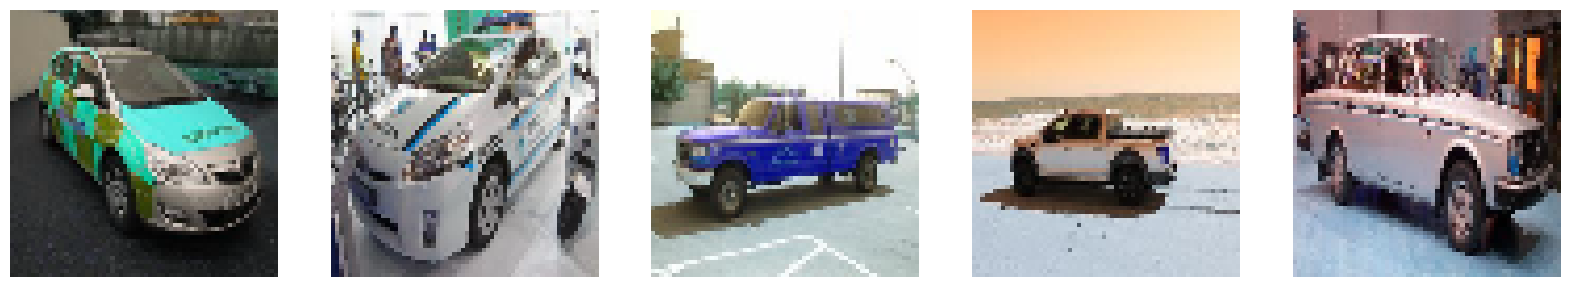

In [12]:
# visualizing images
fig,ax = plt.subplots(nrows=1,ncols=5,figsize=(20,20))
for i in range(5):
    ax[i].imshow(X[i*400])
    ax[i].axis('off')

## 2. Creating training and validation set

In [13]:
# creating a training and validation set
X_train, X_valid, y_train, y_valid=train_test_split(X,y,test_size=0.3, random_state=seed)

In [14]:
# shape of training and validation set
(X_train.shape, y_train.shape), (X_valid.shape, y_valid.shape)

(((1646, 64, 64, 3), (1646,)), ((706, 64, 64, 3), (706,)))

## 3. Augmenting Images

In [15]:
# augmenting the training images
final_train_data = []
final_target_train = []
for i in tqdm(range(X_train.shape[0])):
    # original image
    final_train_data.append(X_train[i])
    # image rotation
    final_train_data.append(rotate(X_train[i], angle=30, mode = 'edge'))
    # image flipping (left-to-right)
    final_train_data.append(np.fliplr(X_train[i]))
    # image flipping (up-down)
    final_train_data.append(np.flipud(X_train[i]))
    # image noising
    final_train_data.append(random_noise(X_train[i],var=0.2))
    for j in range(5):
        final_target_train.append(y_train[i])

100%|██████████| 1646/1646 [00:02<00:00, 820.30it/s]


In [16]:
# converting images and target to array
final_train = np.array(final_train_data)
final_target_train = np.array(final_target_train)

In [17]:
# shape of new training set
final_train.shape, final_target_train.shape

((8230, 64, 64, 3), (8230,))

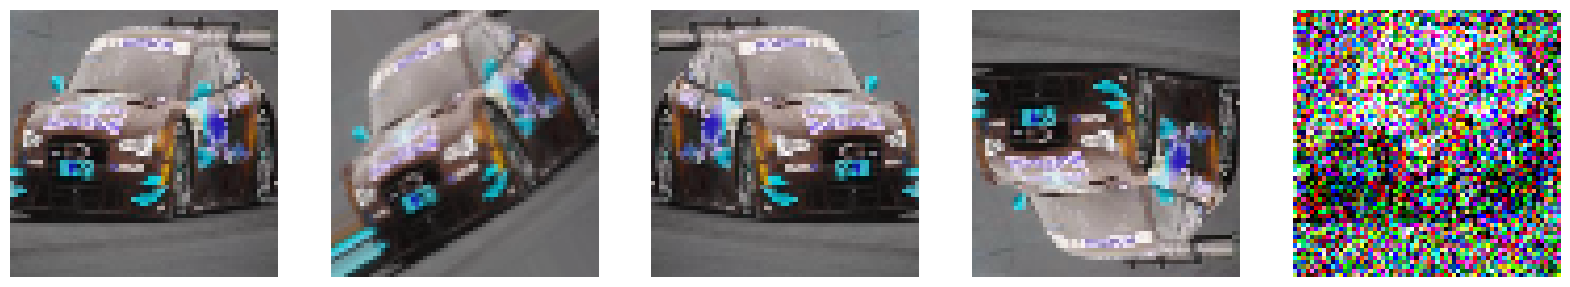

In [18]:
# visualizing the augmented images
fig,ax = plt.subplots(nrows=1,ncols=5,figsize=(20,20))
for i in range(5):
    ax[i].imshow(final_train[i+30])
    ax[i].axis('off')

In [21]:
# converting 3 dimensional image to 1 dimensional image
final_train = final_train.reshape(final_train.shape[0], 64*64*3)
final_train.shape

(8230, 12288)

In [22]:
# minimum and maximum pixel values of training images
final_train.min(), final_train.max()

(np.float64(0.0), np.float64(1.0))

In [23]:
# converting 3 dimensional validation image to 1 dimensional image
final_valid = X_valid.reshape(X_valid.shape[0], 64*64*3)
final_valid.shape

(706, 12288)

In [24]:
# minimum and maximum pixel values of validation images
final_valid.min(), final_valid.max()

(np.float64(0.0), np.float64(1.0))

## 4. Defining the model architecture

In [25]:
# importing functions from keras to define the neural network architecture

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,InputLayer, Dropout, BatchNormalization
# importing adam optimizer from keras optimizer module
from tensorflow.keras.optimizers import Adam

2026-03-09 17:19:41.635454: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773076781.818531     451 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773076781.867191     451 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773076782.299051     451 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773076782.299103     451 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773076782.299106     451 computation_placer.cc:177] computation placer alr

In [26]:
# defining the adam optimizer and setting the learning rate as 10^-5
adam = Adam(learning_rate=1e-5)

I0000 00:00:1773076796.535594     451 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773076796.541594     451 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [27]:
# defining and compiling the model architecture
model=Sequential()


model.add(InputLayer(input_shape=(64*64*3,)))
model.add(Dense(100, activation='sigmoid'))
model.add(BatchNormalization())
model.add(Dropout(rate=0.5))
model.add(Dense(100, activation='sigmoid'))
model.add(BatchNormalization())
model.add(Dropout(rate=0.5))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [28]:
# summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │     1,228,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,239,901 (4.73 MB)

 Trainable params: 1,239,501 (4.73 MB)

 Non-trainable params: 400 (1.56 KB)

## 5. Training the model

In [29]:
# training the model
model_history = model.fit(final_train, final_target_train, epochs=50, batch_size=16,validation_data=(final_valid,y_valid))

Epoch 1/50


I0000 00:00:1773076837.472960     536 service.cc:152] XLA service 0x781ba00057e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773076837.473001     536 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773076837.473005     536 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773076837.897724     536 cuda_dnn.cc:529] Loaded cuDNN version 91002


 57/515 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4759 - loss: 1.1295

I0000 00:00:1773076839.813879     536 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5131 - loss: 1.0522 - val_accuracy: 0.6742 - val_loss: 0.6000
Epoch 2/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5794 - loss: 0.9102 - val_accuracy: 0.6827 - val_loss: 0.5998
Epoch 3/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6032 - loss: 0.8478 - val_accuracy: 0.6884 - val_loss: 0.5878
Epoch 4/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6197 - loss: 0.8074 - val_accuracy: 0.6941 - val_loss: 0.5813
Epoch 5/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6273 - loss: 0.8008 - val_accuracy: 0.7054 - val_loss: 0.5676
Epoch 6/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6378 - loss: 0.7601 - val_accuracy: 0.6969 - val_loss: 0.5782
Epoch 7/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6319 - loss: 0.7698 - val_accuracy: 0.7110 - val_loss: 0.5622
Epoch 8/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6407 - loss: 0.7491 - val_accuracy: 0.7139 - val_

## 6. Evaluating model performance

In [ ]:
y_pred

In [30]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid, np.where(model.predict(final_valid)[:, 0]<0.5, 0, 1)))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Accuracy on validation set: 0.726628895184136


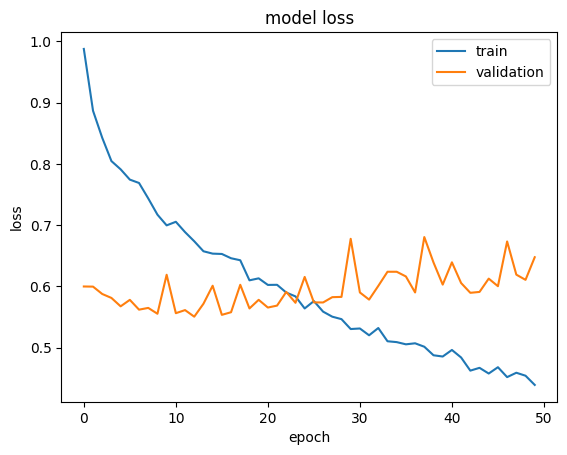

In [32]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

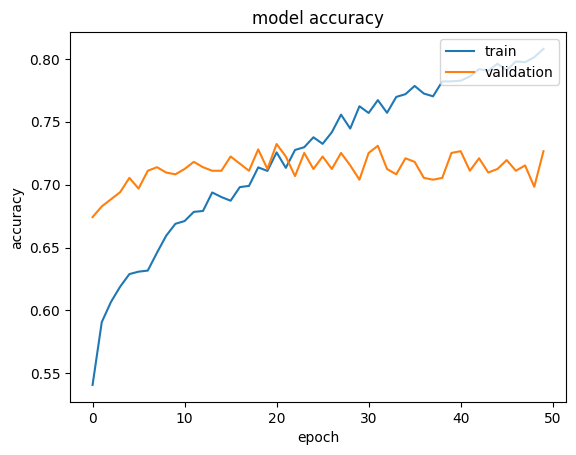

In [33]:
# summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()